<a href="https://colab.research.google.com/github/brittanyasare04/wrangling_assignment/blob/main/assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling
### `! git clone https://github.com/ds3001f25/wrangling_assignment.git`
### Do Q1 and Q2
### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. Numeric variable: For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. Categorical variable: For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?
3. Dummy variable: For the pretrial data covered in the lecture `./data/justice_data.parquet`, clean the `WhetherDefendantWasReleasedPretrial` variable as well as you can, and, in particular, replace missing values with `np.nan`.
4. Missing values, not at random: For the pretrial data covered in the lecture, clean the `ImposedSentenceAllChargeInContactEvent` variable as well as you can, and explain the choices you make. (Hint: Look at the `SentenceTypeAllChargesAtConvictionInContactEvent` variable.)

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?
7. Clean the `Fatal Y/N` variable so it only takes three values: Y, N, and Unknown.
8. Are sharks more likely to launch unprovoked attacks on men or women? Is the attack more or less likely to be fatal when the attack is provoked or unprovoked? Is it more or less likely to be fatal when the victim is male or female? How do you feel about sharks?
9. What proportion of attacks appear to be by white sharks? (Hint: `str.split()` makes a vector of text values into a list of lists, split by spaces.)

In [21]:
!touch BA_wrangling_assignment

In [ ]:
! git clone https://github.com/ds3001f25/wrangling_assignment.git

In [25]:
%cd wrangling_assignment

/content/wrangling_assignment


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
#Loading airbnb dataset
airbnb = pd.read_csv('./wrangling_assignment/data/airbnb_hw.csv')

In [10]:
#Begin to clean the airbnb price data

airbnb['Price'] = airbnb['Price'].str.replace('$', '', regex=True)
airbnb['Price'] = airbnb['Price'].str.replace(',', '')
airbnb['Price'] = airbnb['Price'].astype(float)
airbnb['Price'] = pd.to_numeric(airbnb['Price'], errors='coerce')

In [11]:
#Checking the printed results the data
print(airbnb['Price'].describe())
print("Missing Values:", airbnb['Price'].isna().sum())

count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price, dtype: float64
Missing Values: 0


After removing the "$" and ",", then I coerced the numeric, leading to 0 missing values.

In [32]:
# Code for Q1b.
police_data = pd.read_csv('./data/mn_police_use_of_force.csv')

In [33]:
# Cleaning the police data from the subject_injury
police_data['subject_injury'] = police_data['subject_injury'].replace([' ', 'NA', 'nan'], np.nan)
police_data['subject_injury'] = police_data['subject_injury'].str.strip().str.title()

In [34]:
#Finding the missing proportion
print("Missing Proportion:", police_data['subject_injury'].isnull().mean())

Proportion missing: 0.7619342359767892


The missing proportion here is 76.19%

In [35]:
# Cross-tabulation with force_type
print(pd.crosstab(police_data['subject_injury'], police_data['force_type']))

force_type      Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury                                                    
No                  0          1093                131        2   
Yes                 2          1286                 41        0   

force_type      Gun Point Display  Improvised Weapon  Less Lethal Projectile  \
subject_injury                                                                 
No                             33                 34                       1   
Yes                            44                 40                       2   

force_type      Police K9 Bite  Taser  
subject_injury                         
No                           2    150  
Yes                         44    172  


With the missing proportion being 76.19% and standardinzing the data to yes and no, we are able to determine that injuries were most common from creating the cross-tabulation was tasers, bodily force, and K9 bites. The less common were chemical irritants and firearms.

In [36]:
# Code for section 1c
pretrial_data = pd.read_parquet('./data/justice_data.parquet')

In [37]:
var = 'WhetherDefendantWasReleasedPretrial'
pretrial_data[var] = pretrial_data[var].replace([9,99], np.nan)

After replacing the codes 9 and 99 with NaN, we can consider the variable to be cleaned and relect as 0 and not as 1, as well as NaN as missing.

the WhetherDefendantWasReleasedPretrial column only contained 0 and 1. So when the replacement of 9 and 99, there were no 9s or 99s in the column, hanging to NaN.

In [38]:
# Code for 1d
pd.crosstab(pretrial_data['ImposedSentenceAllChargeInContactEvent'].isnull(),
            pretrial_data['SentenceTypeAllChargesAtConvictionInContactEvent'])

SentenceTypeAllChargesAtConvictionInContactEvent,0,1,2,4,9
ImposedSentenceAllChargeInContactEvent,,,,,
False,8720,4299,914,8779,274


The cross-tabulation reflects ImposedSentenceAllChargeInContactEvent is usually missing when 0 sentence was imposed.

In [40]:
# Question 2
from google.colab import files
uploaded = files.upload()

Saving GSAF5.xls to GSAF5.xls


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [43]:
# Shark attack file being loaded in
shark_attack = pd.read_excel('GSAF5.xls')

In [44]:
# Dropping the empty columns
shark_attack = shark_attack.dropna(axis=1, how='all')
print(shark_attack.shape)
shark_attack.head()

(7042, 23)


,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,16th August 2025,2025.0,Provoked,USA,Florida,Cayo Costa Boca Grande,Fishing,Shawn Meuse,M,?,...,Lemon shark 1.8 m (6ft),Johannes Marchand: Kevin McMurray Trackingshar...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,18th August,2025.0,Unprovoked,Australia,NSW,Cabarita Beach,Surfing,Brad Ross,M,?,...,5m (16.5ft) Great White,Bob Myatt GSAF The Guardian: 9 News: ABS News:...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,17th August,2025.0,Unprovoked,Bahamas,Atlantic Ocean near Big Grand Cay,North of Grand Bahama near Freeport,Spearfishing,Not stated,M,63,...,Undetermined,Ralph Collier GSAF and Kevin MCMurray Tracking...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7th August,2025.0,Unprovoked,Australia,NSW,Tathra Beach,Surfing,Bowie Daley,M,9,...,Suspected Great White,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1st August,2025.0,Unprovoked,Puerto Rico,Carolina,Carolina Beach,Wading,Eleonora Boi,F,39,...,Undetermined,Kevin McMurray Trackingsharks.com: NY Post,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Changing the Year to a Numeric variable
shark_attack['Year'] = pd.to_numeric(shark_attack['Year'], errors='coerce')

In [48]:
#Filtering and Identifying the shark attacks that has happened since the 1940s
shark_attack_updated = shark_attack[shark_attack['Year'] >= 1940]

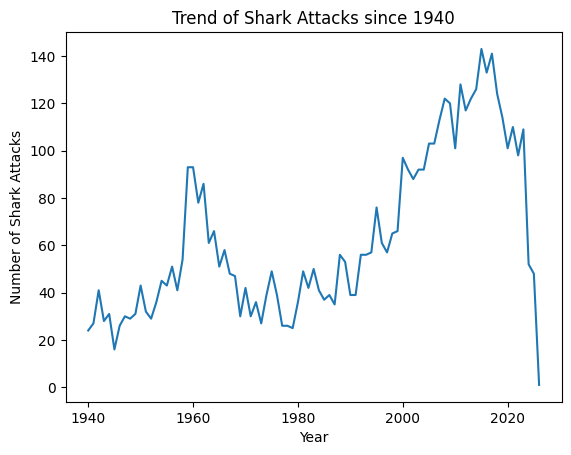

In [49]:
# Plotting the Trend
shark_attack_updated['Year'].value_counts().sort_index().plot(kind='line')
plt.xlabel('Year')
plt.ylabel('Number of Shark Attacks')
plt.title('Trend of Shark Attacks since 1940')
plt.show()

Based on the graph above, it can be inferred that there has been an increase of attacks over time since the 1940s.

In [56]:
# Cleaning of the age variable
def clean_age(age):
    if pd.isnull(age): return np.nan
    x = str(age).strip()
    if x.isdigit(): return int(x)
    if 'teen' in x.lower(): return 15
    if '20' in x: return 25
    if '30' in x: return 35
    return np.nan

In [57]:
shark_attack['Age_clean'] = shark_attack['Age'].apply(clean_age)

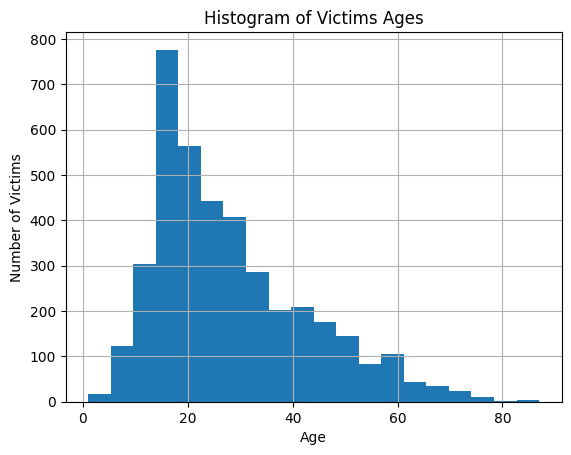

In [58]:
shark_attack['Age_clean'].hist(bins=20)
plt.title("Histogram of Victims Ages")
plt.xlabel("Age")
plt.ylabel("Number of Victims")
plt.show()

We can concluded that majority of the victims ages ranges from their 20s-30s

In [65]:
male_proportion = (shark_attack['Sex'] == 'M').mean()

print("Proportion of male victims:", male_proportion)

Proportion of male victims: 0.8026128940641863


Approximately 80.2% of males are victims to shark attacks.

In [66]:
# Cleaning the variable type
shark_attack['Type'] = shark_attack['Type'].str.strip().str.title()
shark_attack['Type'] = shark_attack['Type'].where(shark_attack['Type'].isin(['Provoked', 'Unprovoked']), 'Unknown')

print(shark_attack['Type'].value_counts(normalize=True))

Type
Unprovoked    0.738001
Unknown       0.170974
Provoked      0.091025
Name: proportion, dtype: float64


Approximately 73.8% of shark attacks are unprovoked.

In [68]:
# Cleaning the Fatality Variable
shark_attack['Fatal_clean'] = shark_attack['Fatal Y/N'].str.strip().str.upper()
shark_attack['Fatal_clean'] = shark_attack['Fatal_clean'].where(shark_attack['Fatal_clean'].isin(['Y', 'N']), 'Unknown')
print(shark_attack['Fatal_clean'].value_counts(normalize=True))

Fatal_clean
N          0.698239
Y          0.210452
Unknown    0.091309
Name: proportion, dtype: float64


Approximately 21% of shark attacks are Fatal

In [ ]:
# Cross Analysis of gender and fatality type

In [81]:
# Unprovoked attacks by gender (male Vs female)
print(pd.crosstab(shark_attack['Type'], shark_attack['Sex'], normalize='columns'))

Sex           .         F  LLI         M  M X 2    N
Type                                                
Provoked    0.0  0.038462  0.0  0.097311    0.0  0.5
Unknown     1.0  0.114144  0.0  0.133935    1.0  0.5
Unprovoked  0.0  0.847395  1.0  0.768754    0.0  0.0


In [74]:
# Types of fatality
print(pd.crosstab(shark_attack['Fatal_clean'], shark_attack['Type'], normalize='columns'))

Type         Provoked   Unknown  Unprovoked
Fatal_clean                                
N            0.953198  0.372924    0.742159
Unknown      0.014041  0.460963    0.015201
Y            0.032761  0.166113    0.242640


In [73]:
# Fatality by Gender
print(pd.crosstab(shark_attack['Fatal_clean'], shark_attack['Sex'], normalize='columns'))

Sex            .         F  LLI         M  M X 2    N
Fatal_clean                                          
N            0.0  0.761787  1.0  0.697275    0.0  0.5
Unknown      0.0  0.086849  0.0  0.081387    1.0  0.0
Y            1.0  0.151365  0.0  0.221338    0.0  0.5


Based on the cross tabulation, we can see that sharks are more likely to launch unprovoked attacks on women. The attack is more likely to fatal when it is unprovoked and lastly, attacks on men are slightly more fatal then when done on women. I am still not the most fond of sharks.

In [80]:
# White Shark Statistic
shark_attack['Species_clean'] = shark_attack['Species '].str.lower().fillna("").str.split()
shark_attack['White_Shark'] = shark_attack['Species_clean'].apply(lambda words: 'white' in words)
proportion_white = shark_attack['White_Shark'].mean()
print("Proportion of attacks by white sharks:", proportion_white)

Proportion of attacks by white sharks: 0.10096563476285146


Approximately 10.1% of attacks are by white sharks.

In [82]:
!git config --global user.name "brittanyasare04"
!git config --global user.email "brittanyasare04@gmail.com"

In [84]:
!git status
!ls -la
!git add <assignment.ipynb> <GSAF5.xls
!git commit -m "Brittany Asare - HW1 complete"
!git push origin main

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	GSAF5.xls

nothing added to commit but untracked files present (use "git add" to track)
total 5764
drwxr-xr-x 4 root root    4096 Sep  2 01:16 .
drwxr-xr-x 1 root root    4096 Sep  1 21:31 ..
-rw-r--r-- 1 root root    4070 Sep  1 21:31 assignment.ipynb
drwxr-xr-x 2 root root    4096 Sep  1 21:31 data
drwxr-xr-x 8 root root    4096 Sep  2 02:40 .git
-rw-r--r-- 1 root root 5510656 Sep  2 01:16 GSAF5.xls
-rw-r--r-- 1 root root     211 Sep  1 21:31 README.md
-rw-r--r-- 1 root root  360450 Sep  1 21:31 tidy_data.pdf
/bin/bash: -c: line 1: syntax error near unexpected token `<'
/bin/bash: -c: line 1: `git add <assignment.ipynb> <GSAF5.xls'
On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	GSAF5.xls

nothing added to commit but untracked files present (use 